<a href="https://colab.research.google.com/github/amathie5/PPS-Project-/blob/main/pps_project_final_part1_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1


In [30]:
## Parameters
horizon = 12    #in months
w_i = 90        # Initial number of workers
p = 10          #Production rate per worker per month
inv_i = 900     # Initial inventory
inv_t = 1000    # Final inventory target by end of December
hold = 1000     # Inventory holding cost per watch per month (security/insurance)
wage_r = 7000   # Regular wage/worker/month
hiring = 50000  # Hiring cost per worker
layoff = 25000  # layoff cost per worker
max_overtime = 0.2  # overtime allowance......
overtime_cost = 14000 # 2x wage_r
subcontracting_cost = 15000 # CHF per watch
max_contracting = 300 # watches per month
overtime_months = [3,5,9,12] # march, may, sept, dec
subcontracting_months = [6,7,10,12] # june, july, oct, dec
demand = [900,950,1200,1050,1100,1300,1250,1100,1300,1450,1500,1700]

In [31]:
pip install pulp numpy pandas matplotlib


In [45]:
import numpy as np
import pandas as pd

def simulate_plan(strategy):

    months = horizon
    workers = np.zeros(months)
    hired = np.zeros(months)
    fired = np.zeros(months)
    production = np.zeros(months)
    overtime_prod = np.zeros(months)
    inventory = np.zeros(months + 1)

    inventory[0] = inv_i

    # ----------------------------
    # LEVEL STRATEGY
    # ----------------------------
    if strategy == "level":

        production_per_month = w_i * p
        workers[:] = w_i

        for t in range(months):
            production[t] = production_per_month
            inventory[t+1] = max(0, inventory[t] + production[t] - demand[t])

    # ----------------------------
    # CHASE STRATEGY
    # ----------------------------
    elif strategy == "chase":

        for t in range(months):

            workers_needed = np.ceil(demand[t] / p)
            workers[t] = workers_needed

            if t == 0:
                hired[t] = max(0, workers[t] - w_i)
                fired[t] = max(0, w_i - workers[t])
            else:
                hired[t] = max(0, workers[t] - workers[t-1])
                fired[t] = max(0, workers[t-1] - workers[t])

            production[t] = workers[t] * p
            inventory[t+1] = max(0, inventory[t] + production[t] - demand[t])

    # ----------------------------
    # MIXED STRATEGY (Level + Overtime)
    # ----------------------------
    elif strategy == "mixed":

        workers[:] = w_i

        for t in range(months):

            reg_prod = workers[t] * p
            production[t] = reg_prod

            # Production disponible
            available = max(0, inventory[t]) + reg_prod
            shortage = max(0, demand[t] - available)

            # Overtime seulement si autorisé
            if shortage > 0 and (t + 1) in overtime_months:
                max_ot = workers[t] * p * max_overtime
                ot_used = min(shortage, max_ot)

                overtime_prod[t] = ot_used
                production[t] += ot_used

            inventory[t+1] = max(0, inventory[t] + production[t] - demand[t])

    # ----------------------------
    # COSTS
    # ----------------------------

    wage_cost = workers * wage_r
    hiring_cost = hired * hiring
    firing_cost = fired * layoff

    ot_unit_cost = overtime_cost / p
    ot_cost = overtime_prod * ot_unit_cost

    inventory_cost = np.maximum(inventory[1:], 0) * hold

    total_cost = (
        wage_cost
        + hiring_cost
        + firing_cost
        + inventory_cost
        + ot_cost
    )

    # ----------------------------
    # RESULTS
    # ----------------------------

    results = pd.DataFrame({
        "Month": range(1, months+1),
        "Workers": workers,
        "Hired": hired,
        "Fired": fired,
        "Regular Prod": np.maximum(0, production - overtime_prod),
        "Overtime Prod": overtime_prod,
        "Total Prod": production,
        "Demand": demand,
        "Inventory": inventory[1:],
        "Total Cost": total_cost
    })

    summary = {
        "Total Wage": wage_cost.sum(),
        "Total Hiring": hiring_cost.sum(),
        "Total Layoff": firing_cost.sum(),
        "Total Overtime": ot_cost.sum(),
        "Total Inventory": inventory_cost.sum(),
        "Grand Total": total_cost.sum()
    }

    return results, summary

In [46]:
#level strategy
level_table, level_cost = simulate_plan("level")

display(level_table)
display(level_cost)

,Month,Workers,Hired,Fired,Regular Prod,Overtime Prod,Total Prod,Demand,Inventory,Total Cost
0,1,90.0,0.0,0.0,900.0,0.0,900.0,900,900.0,1530000.0
1,2,90.0,0.0,0.0,900.0,0.0,900.0,950,850.0,1480000.0
2,3,90.0,0.0,0.0,900.0,0.0,900.0,1200,550.0,1180000.0
3,4,90.0,0.0,0.0,900.0,0.0,900.0,1050,400.0,1030000.0
4,5,90.0,0.0,0.0,900.0,0.0,900.0,1100,200.0,830000.0
5,6,90.0,0.0,0.0,900.0,0.0,900.0,1300,0.0,630000.0
6,7,90.0,0.0,0.0,900.0,0.0,900.0,1250,0.0,630000.0
7,8,90.0,0.0,0.0,900.0,0.0,900.0,1100,0.0,630000.0
8,9,90.0,0.0,0.0,900.0,0.0,900.0,1300,0.0,630000.0
9,10,90.0,0.0,0.0,900.0,0.0,900.0,1450,0.0,630000.0


{'Total Wage': np.float64(7560000.0),
 'Total Hiring': np.float64(0.0),
 'Total Layoff': np.float64(0.0),
 'Total Overtime': np.float64(0.0),
 'Total Inventory': np.float64(2900000.0),
 'Grand Total': np.float64(10460000.0)}

In [47]:
chase_table, chase_cost = simulate_plan("chase")

display(chase_table)
display(chase_cost)

,Month,Workers,Hired,Fired,Regular Prod,Overtime Prod,Total Prod,Demand,Inventory,Total Cost
0,1,90.0,0.0,0.0,900.0,0.0,900.0,900,900.0,1530000.0
1,2,95.0,5.0,0.0,950.0,0.0,950.0,950,900.0,1815000.0
2,3,120.0,25.0,0.0,1200.0,0.0,1200.0,1200,900.0,2990000.0
3,4,105.0,0.0,15.0,1050.0,0.0,1050.0,1050,900.0,2010000.0
4,5,110.0,5.0,0.0,1100.0,0.0,1100.0,1100,900.0,1920000.0
5,6,130.0,20.0,0.0,1300.0,0.0,1300.0,1300,900.0,2810000.0
6,7,125.0,0.0,5.0,1250.0,0.0,1250.0,1250,900.0,1900000.0
7,8,110.0,0.0,15.0,1100.0,0.0,1100.0,1100,900.0,2045000.0
8,9,130.0,20.0,0.0,1300.0,0.0,1300.0,1300,900.0,2810000.0
9,10,145.0,15.0,0.0,1450.0,0.0,1450.0,1450,900.0,2665000.0


{'Total Wage': np.float64(10360000.0),
 'Total Hiring': np.float64(5750000.0),
 'Total Layoff': np.float64(875000.0),
 'Total Overtime': np.float64(0.0),
 'Total Inventory': np.float64(10800000.0),
 'Grand Total': np.float64(27785000.0)}

In [48]:
mixed_table, mixed_cost = simulate_plan("mixed")
display(mixed_table)
display(mixed_cost)

,Month,Workers,Hired,Fired,Regular Prod,Overtime Prod,Total Prod,Demand,Inventory,Total Cost
0,1,90.0,0.0,0.0,900.0,0.0,900.0,900,900.0,1530000.0
1,2,90.0,0.0,0.0,900.0,0.0,900.0,950,850.0,1480000.0
2,3,90.0,0.0,0.0,900.0,0.0,900.0,1200,550.0,1180000.0
3,4,90.0,0.0,0.0,900.0,0.0,900.0,1050,400.0,1030000.0
4,5,90.0,0.0,0.0,900.0,0.0,900.0,1100,200.0,830000.0
5,6,90.0,0.0,0.0,900.0,0.0,900.0,1300,0.0,630000.0
6,7,90.0,0.0,0.0,900.0,0.0,900.0,1250,0.0,630000.0
7,8,90.0,0.0,0.0,900.0,0.0,900.0,1100,0.0,630000.0
8,9,90.0,0.0,0.0,900.0,180.0,1080.0,1300,0.0,882000.0
9,10,90.0,0.0,0.0,900.0,0.0,900.0,1450,0.0,630000.0


{'Total Wage': np.float64(7560000.0),
 'Total Hiring': np.float64(0.0),
 'Total Layoff': np.float64(0.0),
 'Total Overtime': np.float64(504000.0),
 'Total Inventory': np.float64(2900000.0),
 'Grand Total': np.float64(10964000.0)}

In [51]:
level_results, level_summary = simulate_plan("level")
chase_results, chase_summary = simulate_plan("chase")
mixed_results, mixed_summary = simulate_plan("mixed")

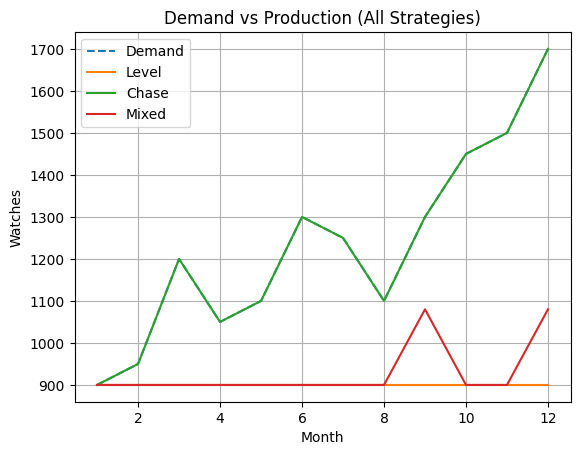

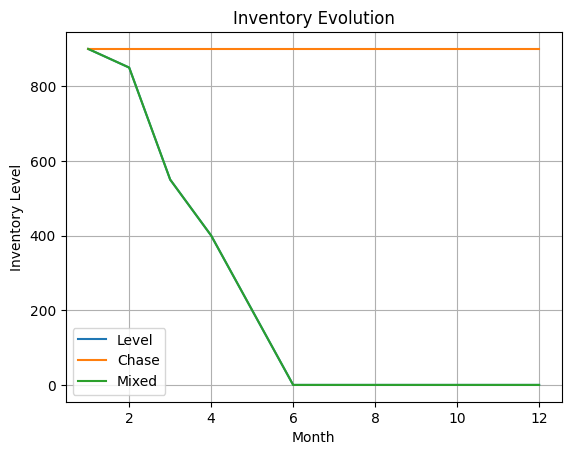

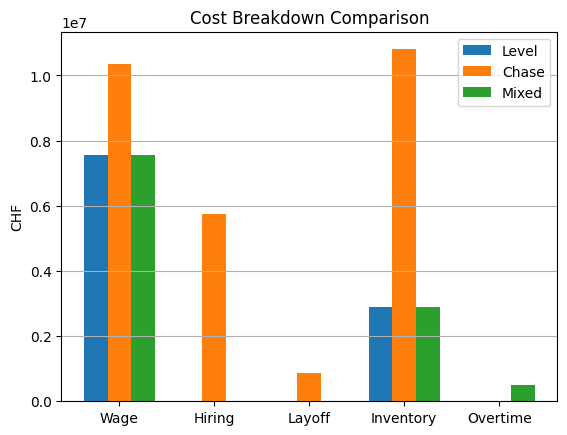

In [52]:
import matplotlib.pyplot as plt

# =========================
# 1. DEMAND vs PRODUCTION
# =========================

plt.figure()

plt.plot(level_results["Month"], level_results["Demand"], linestyle="--", label="Demand")
plt.plot(level_results["Month"], level_results["Total Prod"], label="Level")
plt.plot(chase_results["Month"], chase_results["Total Prod"], label="Chase")
plt.plot(mixed_results["Month"], mixed_results["Total Prod"], label="Mixed")

plt.title("Demand vs Production (All Strategies)")
plt.xlabel("Month")
plt.ylabel("Watches")
plt.legend()
plt.grid()

plt.show()


# =========================
# 2. INVENTORY EVOLUTION
# =========================

plt.figure()

plt.plot(level_results["Month"], level_results["Inventory"], label="Level")
plt.plot(chase_results["Month"], chase_results["Inventory"], label="Chase")
plt.plot(mixed_results["Month"], mixed_results["Inventory"], label="Mixed")

plt.title("Inventory Evolution")
plt.xlabel("Month")
plt.ylabel("Inventory Level")
plt.legend()
plt.grid()

plt.show()


# =========================
# 3. COST BREAKDOWN
# =========================

labels = ["Wage", "Hiring", "Layoff", "Inventory", "Overtime"]

level_costs = [
    level_summary["Total Wage"],
    level_summary["Total Hiring"],
    level_summary["Total Layoff"],
    level_summary["Total Inventory"],
    level_summary["Total Overtime"]
]

chase_costs = [
    chase_summary["Total Wage"],
    chase_summary["Total Hiring"],
    chase_summary["Total Layoff"],
    chase_summary["Total Inventory"],
    chase_summary["Total Overtime"]
]

mixed_costs = [
    mixed_summary["Total Wage"],
    mixed_summary["Total Hiring"],
    mixed_summary["Total Layoff"],
    mixed_summary["Total Inventory"],
    mixed_summary["Total Overtime"]
]

x = range(len(labels))

plt.figure()

plt.bar([i - 0.25 for i in x], level_costs, width=0.25, label="Level")
plt.bar(x, chase_costs, width=0.25, label="Chase")
plt.bar([i + 0.25 for i in x], mixed_costs, width=0.25, label="Mixed")

plt.xticks(x, labels)
plt.title("Cost Breakdown Comparison")
plt.ylabel("CHF")
plt.legend()
plt.grid(axis="y")

plt.show()

# Part 2

In [61]:
#---------------------------
# Model Base
#---------------------------


from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpInteger, LpContinuous, LpStatus, value
import pandas as pd
import numpy as np

def solve_lp_model_1(
    demand,
    p,
    inv_i,
    inv_t,
    w_i,
    wage_r,
    hiring,
    layoff,
    hold
):
    months = len(demand)

    # Initialisation du modèle
    model = LpProblem("Aurelius_Base_Model", LpMinimize)

    # Variables de décision
    W = LpVariable.dicts("W", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("H", range(months), lowBound=0, cat=LpInteger)
    L = LpVariable.dicts("L", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("P", range(months), lowBound=0, cat=LpContinuous)
    I = LpVariable.dicts("I", range(months), lowBound=0, cat=LpContinuous)



    # Fonction objectif : Minimiser le coût total
    model += lpSum(
        W[t] * wage_r +
        H[t] * hiring +
        L[t] * layoff +
        I[t] * hold
        for t in range(months)
    ), "Total_Cost"

    # Contraintes
    for t in range(months):
        model += I[t] >= 0

        # 1. Contrainte de capacité de production
        model += P[t] <= W[t] * p, f"Prod_Capacity_Month_{t}"

        # 2. Équilibre de la main-d'œuvre et de l'inventaire
        if t == 0:
            model += W[t] == w_i + H[t] - L[t], "Workforce_Balance_Month_0"
            model += I[t] == inv_i + P[t] - demand[t], "Inventory_Balance_Month_0"
        else:
            model += W[t] == W[t-1] + H[t] - L[t], f"Workforce_Balance_Month_{t}"
            model += I[t] == I[t-1] + P[t] - demand[t], f"Inventory_Balance_Month_{t}"

    # 3. Cible d'inventaire à la fin de l'horizon (Décembre)
    model += I[months - 1] >= inv_t, "Final_Inventory_Target"

    # Résolution
    model.solve()

    status = LpStatus[model.status]

    # Extraction des résultats si la solution est optimale
    if status == "Optimal":
        df = pd.DataFrame({
            "Month": np.arange(1, months+1),
            "Workers": [W[t].varValue for t in range(months)],
            "Hired": [H[t].varValue for t in range(months)],
            "Laid off": [L[t].varValue for t in range(months)],
            "Produced": [P[t].varValue for t in range(months)],
            "Demand": demand,
            "End Inventory": [I[t].varValue for t in range(months)],
        })

        summary = {
            "Total Wage": sum(W[t].varValue * wage_r for t in range(months)),
            "Total Hiring": sum(H[t].varValue * hiring for t in range(months)),
            "Total Layoff": sum(L[t].varValue * layoff for t in range(months)),
            "Total Inventory": sum(I[t].varValue * hold for t in range(months)),
            "Grand Total": value(model.objective)
        }
    else:
        df = pd.DataFrame()
        summary = {}

    return df, summary, status

In [62]:
df_model1, summary_model1, status_model1 = solve_lp_model_1(demand, p, inv_i, inv_t, w_i, wage_r, hiring, layoff, hold)
display(df_model1)
display(summary_model1)

,Month,Workers,Hired,Laid off,Produced,Demand,End Inventory
0,1,90.0,0.0,0.0,0.0,900,0.0
1,2,100.0,10.0,0.0,1000.0,950,50.0
2,3,115.0,15.0,0.0,1150.0,1200,0.0
3,4,115.0,0.0,0.0,1050.0,1050,0.0
4,5,115.0,0.0,0.0,1150.0,1100,50.0
5,6,125.0,10.0,0.0,1250.0,1300,0.0
6,7,125.0,0.0,0.0,1250.0,1250,0.0
7,8,125.0,0.0,0.0,1100.0,1100,0.0
8,9,131.0,6.0,0.0,1310.0,1300,10.0
9,10,188.0,57.0,0.0,1880.0,1450,440.0


{'Total Wage': 11235000.0,
 'Total Hiring': 4900000.0,
 'Total Layoff': 0.0,
 'Total Inventory': 2370000.0,
 'Grand Total': 18505000.0}

In [38]:
#-------------------------
# Model 2 : overtime only
#-------------------------

def solve_lp_model_2(
    demand,
    p,
    inv_i,
    inv_t,
    w_i,
    wage_r,
    hiring,
    layoff,
    hold,
    overtime_cost,
    max_overtime,
    overtime_months
):
    months = len(demand)

    model = LpProblem("Aurelius_Model_2_Overtime", LpMinimize)

    # Variables
    W = LpVariable.dicts("W", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("H", range(months), lowBound=0, cat=LpInteger)
    L = LpVariable.dicts("L", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("P", range(months), lowBound=0)
    I = LpVariable.dicts("I", range(months), lowBound=0)
    O = LpVariable.dicts("O", range(months), lowBound=0)
    T = LpVariable.dicts("T", range(months), lowBound=0)

    ot_unit_cost = overtime_cost / p

    # Objective
    model += lpSum(
        W[t]*wage_r +
        H[t]*hiring +
        L[t]*layoff +
        I[t]*hold +
        O[t]*ot_unit_cost
        for t in range(months)
    )

    # Constraints
    for t in range(months):

        # Production capacity
        model += P[t] <= W[t] * p

        # Overtime
        if (t+1) in overtime_months:
            model += O[t] <= W[t] * p * max_overtime
        else:
            model += O[t] == 0

        # Total production
        model += T[t] == P[t] + O[t]

        # Workforce balance
        if t == 0:
            model += W[t] == w_i + H[t] - L[t]
            model += I[t] == inv_i + T[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - L[t]
            model += I[t] == I[t-1] + T[t] - demand[t]

    model += I[months-1] >= inv_t

    model.solve()
    status = LpStatus[model.status]

    if status == "Optimal":
        df = pd.DataFrame({
            "Month": np.arange(1, months+1),
            "Workers": [W[t].varValue for t in range(months)],
            "Hired": [H[t].varValue for t in range(months)],
            "Laid off": [L[t].varValue for t in range(months)],
            "Reg. Prod": [P[t].varValue for t in range(months)],
            "Overtime Prod": [O[t].varValue for t in range(months)],
            "Total Prod": [T[t].varValue for t in range(months)],
            "Demand": demand,
            "End Inventory": [I[t].varValue for t in range(months)],
        })

        summary = {
            "Total Wage": sum(W[t].varValue * wage_r for t in range(months)),
            "Total Hiring": sum(H[t].varValue * hiring for t in range(months)),
            "Total Layoff": sum(L[t].varValue * layoff for t in range(months)),
            "Total Overtime": sum(O[t].varValue * ot_unit_cost for t in range(months)),
            "Total Inventory": sum(I[t].varValue * hold for t in range(months)),
            "Grand Total": value(model.objective)
        }
    else:
        df = pd.DataFrame()
        summary = {}

    return df, summary, status

In [39]:
df_model2, summary_model2, status_model2 = solve_lp_model_2(demand, p, inv_i, inv_t, w_i, wage_r, hiring, layoff, hold, overtime_cost, max_overtime,overtime_months)
display(df_model2)
display(summary_model2)

,Month,Workers,Hired,Laid off,Reg. Prod,Overtime Prod,Total Prod,Demand,End Inventory
0,1,90.0,0.0,0.0,0.0,0.0,0.0,900,0.0
1,2,95.0,5.0,0.0,950.0,0.0,950.0,950,0.0
2,3,105.0,10.0,0.0,1050.0,150.0,1200.0,1200,0.0
3,4,105.0,0.0,0.0,1050.0,0.0,1050.0,1050,0.0
4,5,115.0,10.0,0.0,1150.0,0.0,1150.0,1100,50.0
5,6,125.0,10.0,0.0,1250.0,0.0,1250.0,1300,0.0
6,7,125.0,0.0,0.0,1250.0,0.0,1250.0,1250,0.0
7,8,125.0,0.0,0.0,1100.0,0.0,1100.0,1100,0.0
8,9,132.0,7.0,0.0,1318.0,0.0,1318.0,1300,18.0
9,10,176.0,44.0,0.0,1760.0,0.0,1760.0,1450,328.0


{'Total Wage': 10815000.0,
 'Total Hiring': 4300000.0,
 'Total Layoff': 0.0,
 'Total Overtime': 702800.0,
 'Total Inventory': 1984000.0,
 'Grand Total': 17801800.0}

In [40]:
#--------------------------------
# Model 3 : subcontracting only
#---------------------------------

def solve_lp_model_3(
    demand,
    p,
    inv_i,
    inv_t,
    w_i,
    wage_r,
    hiring,
    layoff,
    hold,
    subcontracting_cost,
    max_contracting,
    subcontracting_months
):
    months = len(demand)

    model = LpProblem("Aurelius_Model_3_Subcontracting", LpMinimize)

    # Variables
    W = LpVariable.dicts("W", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("H", range(months), lowBound=0, cat=LpInteger)
    L = LpVariable.dicts("L", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("P", range(months), lowBound=0)
    I = LpVariable.dicts("I", range(months), lowBound=0)
    S = LpVariable.dicts("S", range(months), lowBound=0)
    T = LpVariable.dicts("T", range(months), lowBound=0)

    # Objective
    model += lpSum(
        W[t]*wage_r +
        H[t]*hiring +
        L[t]*layoff +
        I[t]*hold +
        S[t]*subcontracting_cost
        for t in range(months)
    )

    # Constraints
    for t in range(months):

        # Production capacity
        model += P[t] <= W[t] * p

        # Subcontracting
        if (t+1) in subcontracting_months:
            model += S[t] <= max_contracting
        else:
            model += S[t] == 0

        # Total production
        model += T[t] == P[t] + S[t]

        # Workforce balance
        if t == 0:
            model += W[t] == w_i + H[t] - L[t]
            model += I[t] == inv_i + T[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - L[t]
            model += I[t] == I[t-1] + T[t] - demand[t]

    model += I[months-1] >= inv_t

    model.solve()
    status = LpStatus[model.status]

    if status == "Optimal":
        df = pd.DataFrame({
            "Month": np.arange(1, months+1),
            "Workers": [W[t].varValue for t in range(months)],
            "Hired": [H[t].varValue for t in range(months)],
            "Laid off": [L[t].varValue for t in range(months)],
            "Reg. Prod": [P[t].varValue for t in range(months)],
            "Subcontracted": [S[t].varValue for t in range(months)],
            "Total Prod": [T[t].varValue for t in range(months)],
            "Demand": demand,
            "End Inventory": [I[t].varValue for t in range(months)],
        })

        summary = {
            "Total Wage": sum(W[t].varValue * wage_r for t in range(months)),
            "Total Hiring": sum(H[t].varValue * hiring for t in range(months)),
            "Total Layoff": sum(L[t].varValue * layoff for t in range(months)),
            "Total Subcontracting": sum(S[t].varValue * subcontracting_cost for t in range(months)),
            "Total Inventory": sum(I[t].varValue * hold for t in range(months)),
            "Grand Total": value(model.objective)
        }
    else:
        df = pd.DataFrame()
        summary = {}

    return df, summary, status

In [41]:
df_model3, summary_model3, status_model3 = solve_lp_model_3(demand, p, inv_i, inv_t, w_i, wage_r, hiring, layoff, hold, subcontracting_cost, max_contracting, subcontracting_months)
display(df_model3)
display(summary_model3)


,Month,Workers,Hired,Laid off,Reg. Prod,Subcontracted,Total Prod,Demand,End Inventory
0,1,90.0,0.0,0.0,0.0,0.0,0.0,900,0.0
1,2,100.0,10.0,0.0,1000.0,0.0,1000.0,950,50.0
2,3,115.0,15.0,0.0,1150.0,0.0,1150.0,1200,0.0
3,4,115.0,0.0,0.0,1050.0,0.0,1050.0,1050,0.0
4,5,115.0,0.0,0.0,1150.0,0.0,1150.0,1100,50.0
5,6,125.0,10.0,0.0,1250.0,0.0,1250.0,1300,0.0
6,7,125.0,0.0,0.0,1250.0,0.0,1250.0,1250,0.0
7,8,125.0,0.0,0.0,1100.0,0.0,1100.0,1100,0.0
8,9,131.0,6.0,0.0,1310.0,0.0,1310.0,1300,10.0
9,10,188.0,57.0,0.0,1880.0,0.0,1880.0,1450,440.0


{'Total Wage': 11235000.0,
 'Total Hiring': 4900000.0,
 'Total Layoff': 0.0,
 'Total Subcontracting': 0.0,
 'Total Inventory': 2370000.0,
 'Grand Total': 18505000.0}

In [44]:
#-----------------------------------
def solve_lp_model_4(
    demand,
    p,
    inv_i,
    inv_t,
    w_i,
    wage_r,
    hiring,
    layoff,
    hold,
    overtime_cost,
    max_overtime,
    overtime_months,
    subcontracting_cost,
    max_contracting,
    subcontracting_months
):
    months = len(demand)

    # Model
    model = LpProblem("Aurelius_Model_4_Full_Flexibility", LpMinimize)

    # Decision variables
    W = LpVariable.dicts("W", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("H", range(months), lowBound=0, cat=LpInteger)
    L = LpVariable.dicts("L", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("P", range(months), lowBound=0, cat=LpContinuous)
    I = LpVariable.dicts("I", range(months), lowBound=0, cat=LpContinuous)
    O = LpVariable.dicts("O", range(months), lowBound=0, cat=LpContinuous)
    S = LpVariable.dicts("S", range(months), lowBound=0, cat=LpContinuous)
    T = LpVariable.dicts("T", range(months), lowBound=0, cat=LpContinuous)

    # Overtime unit cost
    ot_unit_cost = overtime_cost / p

    # Objective
    model += lpSum(
        W[t] * wage_r +
        H[t] * hiring +
        L[t] * layoff +
        I[t] * hold +
        O[t] * ot_unit_cost +
        S[t] * subcontracting_cost
        for t in range(months)
    )

    # Constraints
    for t in range(months):

        # Production capacity (amélioré)
        model += P[t] <= W[t] * p

        # Overtime
        if (t + 1) in overtime_months:
            model += O[t] <= W[t] * p * max_overtime
        else:
            model += O[t] == 0

        # Subcontracting
        if (t + 1) in subcontracting_months:
            model += S[t] <= max_contracting
        else:
            model += S[t] == 0

        # Total production
        model += T[t] == P[t] + O[t] + S[t]

        # Workforce balance
        if t == 0:
            model += W[t] == w_i + H[t] - L[t]
            model += I[t] == inv_i + T[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - L[t]
            model += I[t] == I[t-1] + T[t] - demand[t]

    # Final inventory constraint
    model += I[months - 1] >= inv_t

    # Solve
    model.solve()
    status = LpStatus[model.status]



    # Results
    if status == "Optimal":
        df = pd.DataFrame({
            "Month": np.arange(1, months+1),
            "Workers": [W[t].varValue for t in range(months)],
            "Hired": [H[t].varValue for t in range(months)],
            "Laid off": [L[t].varValue for t in range(months)],
            "Reg. Prod": [P[t].varValue for t in range(months)],
            "Overtime Prod": [O[t].varValue for t in range(months)],
            "Subcontracted": [S[t].varValue for t in range(months)],
            "Total Prod": [T[t].varValue for t in range(months)],
            "Demand": demand,
            "End Inventory": [I[t].varValue for t in range(months)],
        })

        summary = {
            "Total Wage": sum(W[t].varValue * wage_r for t in range(months)),
            "Total Hiring": sum(H[t].varValue * hiring for t in range(months)),
            "Total Layoff": sum(L[t].varValue * layoff for t in range(months)),
            "Total Overtime": sum(O[t].varValue * ot_unit_cost for t in range(months)),
            "Total Subcontracting": sum(S[t].varValue * subcontracting_cost for t in range(months)),
            "Total Inventory": sum(I[t].varValue * hold for t in range(months)),
            "Grand Total": value(model.objective)
        }

    else:
        df = pd.DataFrame()
        summary = {}

    return df, summary, status

In [43]:
df_model4, summary_model4, status_model4 = solve_lp_model_4(demand, p, inv_i, inv_t, w_i, wage_r, hiring, layoff, hold, overtime_cost, max_overtime, overtime_months, subcontracting_cost, max_contracting, subcontracting_months)
display(df_model4)
display(summary_model4)

,Month,Workers,Hired,Laid off,Reg. Prod,Overtime Prod,Subcontracted,Total Prod,Demand,End Inventory
0,1,90.0,0.0,0.0,0.0,0.0,0.0,0.0,900,0.0
1,2,95.0,5.0,0.0,950.0,0.0,0.0,950.0,950,0.0
2,3,105.0,10.0,0.0,1050.0,150.0,0.0,1200.0,1200,0.0
3,4,105.0,0.0,0.0,1050.0,0.0,0.0,1050.0,1050,0.0
4,5,115.0,10.0,0.0,1150.0,0.0,0.0,1150.0,1100,50.0
5,6,125.0,10.0,0.0,1250.0,0.0,0.0,1250.0,1300,0.0
6,7,125.0,0.0,0.0,1250.0,0.0,0.0,1250.0,1250,0.0
7,8,125.0,0.0,0.0,1100.0,0.0,0.0,1100.0,1100,0.0
8,9,132.0,7.0,0.0,1318.0,0.0,0.0,1318.0,1300,18.0
9,10,176.0,44.0,0.0,1760.0,0.0,0.0,1760.0,1450,328.0


{'Total Wage': 10815000.0,
 'Total Hiring': 4300000.0,
 'Total Layoff': 0.0,
 'Total Overtime': 702800.0,
 'Total Subcontracting': 0.0,
 'Total Inventory': 1984000.0,
 'Grand Total': 17801800.0}

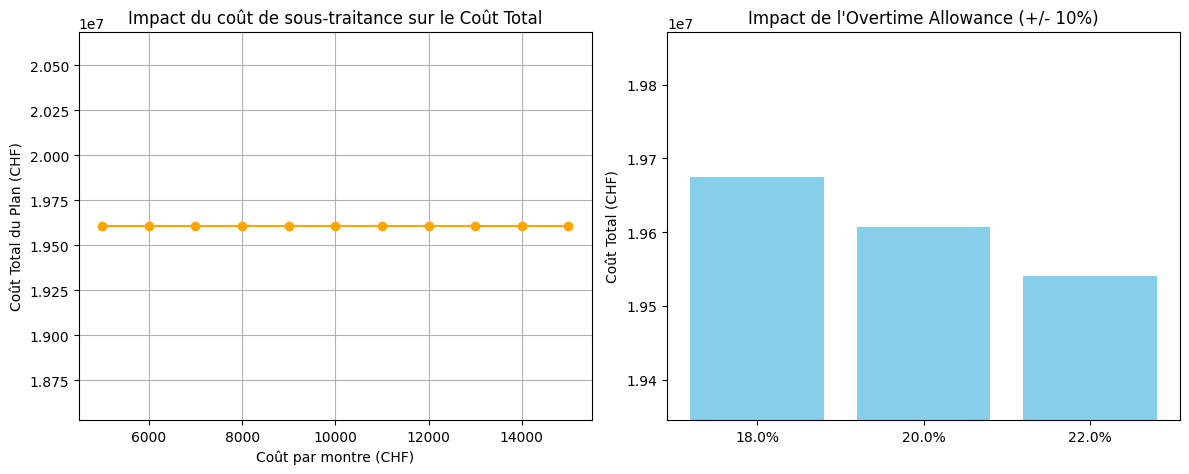

Tableau de sensibilité Overtime :


,Value,Total Cost
0,0.18,19674400.0
1,0.20,19607000.0
2,0.22,19540800.0


In [16]:
#-------------------------------
# 2.3. Sensitivity Analyis
#--------------------------------

import matplotlib.pyplot as plt

# 1. Fonction pour automatiser les tests de sensibilité
def run_sensitivity_analysis(param_name, values):
    results = []

    for val in values:
        # On copie les paramètres de base
        params = {
            "demand": demand, "p": p, "inv_i": inv_i, "inv_t": inv_t,
            "w_i": w_i, "wage_r": wage_r, "hiring": hiring, "layoff": layoff, "hold": hold,
            "overtime_cost": overtime_cost, "max_overtime": max_overtime,
            "overtime_months": overtime_months, "subcontracting_cost": subcontracting_cost,
            "max_contracting": max_contracting, "subcontracting_months": subcontracting_months
        }

        # On modifie le paramètre testé
        params[param_name] = val

        # On résout le Modèle 4 (Full Flexibility)
        _, summary, status = solve_lp_model_4(**params)

        if status == "Optimal":
            results.append({"Value": val, "Total Cost": summary["Grand Total"]})

    return pd.DataFrame(results)

# --- EXECUTION DE L'ANALYSE ---

# A. Sensibilité au coût de sous-traitance (pour voir quand il devient rentable)
# On teste des valeurs de 15000 (base) jusqu'à 5000 CHF
sub_costs = np.arange(5000, 16000, 1000)
df_sens_sub = run_sensitivity_analysis("subcontracting_cost", sub_costs)

# B. Sensibilité à l'Overtime Allowance (+/- 10%)
# 20% * 0.9 = 18% | 20% * 1.1 = 22%
ot_allowances = [0.18, 0.20, 0.22]
df_sens_ot = run_sensitivity_analysis("max_overtime", ot_allowances)

# --- VISUALISATION INTERACTIVE ---

plt.figure(figsize=(12, 5))

# Graphique Coût Sous-traitance
plt.subplot(1, 2, 1)
plt.plot(df_sens_sub["Value"], df_sens_sub["Total Cost"], marker="o", color="orange")
plt.title("Impact du coût de sous-traitance sur le Coût Total")
plt.xlabel("Coût par montre (CHF)")
plt.ylabel("Coût Total du Plan (CHF)")
plt.grid(True)

# Graphique Overtime Allowance
plt.subplot(1, 2, 2)
plt.bar([str(v*100)+"%" for v in df_sens_ot["Value"]], df_sens_ot["Total Cost"], color="skyblue")
plt.title("Impact de l'Overtime Allowance (+/- 10%)")
plt.ylabel("Coût Total (CHF)")
plt.ylim(df_sens_ot["Total Cost"].min() * 0.99, df_sens_ot["Total Cost"].max() * 1.01)

plt.tight_layout()
plt.show()

print("Tableau de sensibilité Overtime :")
display(df_sens_ot)

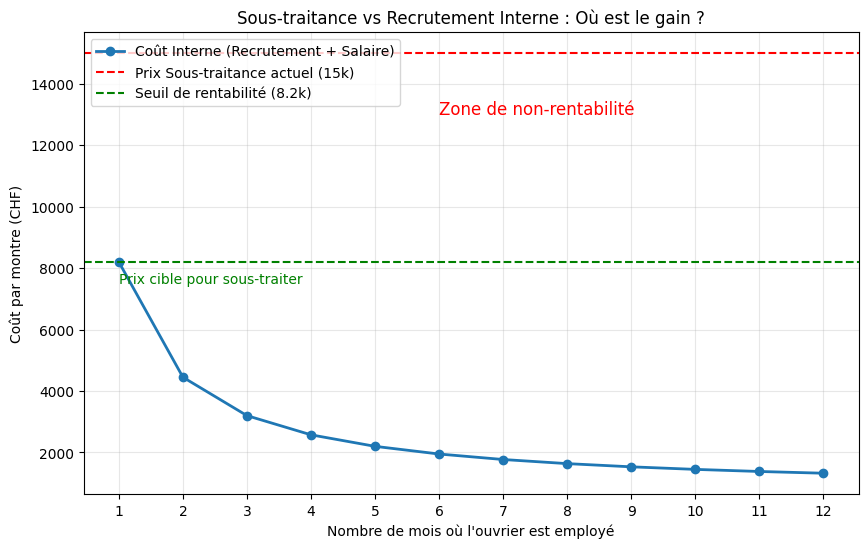

In [17]:
# Données de calcul
n_mois = np.arange(1, 13)
# Formule : (Hiring + n*Wage + Layoff) / (n*10)
cout_interne_par_montre = (50000 + n_mois * 7000 + 25000) / (n_mois * 10)
prix_sous_traitance_actuel = 15000
seuil_critique = 8200

plt.figure(figsize=(10, 6))
plt.plot(n_mois, cout_interne_par_montre, marker="o", label="Coût Interne (Recrutement + Salaire)", linewidth=2)
plt.axhline(y=prix_sous_traitance_actuel, color="red", linestyle="--", label="Prix Sous-traitance actuel (15k)")
plt.axhline(y=seuil_critique, color="green", linestyle="--", label="Seuil de rentabilité (8.2k)")

plt.title("Sous-traitance vs Recrutement Interne : Où est le gain ?")
plt.xlabel("Nombre de mois où l'ouvrier est employé")
plt.ylabel("Coût par montre (CHF)")
plt.xticks(n_mois)
plt.grid(True, alpha=0.3)
plt.legend()
plt.annotate("Zone de non-rentabilité", xy=(6, 13000), color="red", fontsize=12)
plt.annotate("Prix cible pour sous-traiter", xy=(1, 7500), color="green", fontsize=10)

plt.show()

## Part 3

In [63]:
import matplotlib.pyplot as plt
from scipy.stats import norm as normSci
import numpy as np
import pandas as pd
from google.colab import files
import io
from pylab import  *


In [65]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_1 = pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df_1.head()

Saving Demand_data (1).csv to Demand_data (1).csv


,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
0,1,15,12,13,8,147,46,6
1,2,11,14,9,8,106,49,4
2,3,16,10,12,9,154,48,8
3,4,12,7,8,10,80,48,7
4,5,16,6,14,8,176,44,4


In [66]:
df_1.describe()

,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,14.260274,15.178082,14.210959,8.016438,150.723288,47.805479,8.005479
std,105.510663,3.561190,4.281132,3.587507,0.994354,41.180021,5.093950,3.032783
min,1.000000,5.000000,4.000000,4.000000,5.000000,40.000000,35.000000,0.000000
25%,92.000000,12.000000,12.000000,12.000000,7.000000,122.000000,44.000000,6.000000
50%,183.000000,14.000000,15.000000,14.000000,8.000000,147.000000,48.000000,8.000000
75%,274.000000,17.000000,18.000000,17.000000,9.000000,175.000000,51.000000,10.000000
max,365.000000,25.000000,29.000000,25.000000,12.000000,298.000000,63.000000,17.000000


In [67]:
components = df_1.columns[1:]

mean_demand = df_1[components].mean()
std_demand = df_1[components].std()

summary = pd.DataFrame({
"Mean Demand": mean_demand,
"Std Demand": std_demand
})

summary

,Mean Demand,Std Demand
3235 Movement (units),14.260274,3.561190
Oystersteel Case (units),15.178082,4.281132
Sapphire Crystal (units),14.210959,3.587507
Jubilee Bracelet (units),8.016438,0.994354
Lubricant Oil (grams),150.723288,41.180021
Diamond Marker (units),47.805479,5.093950
Gold Crown (units),8.005479,3.032783


In [68]:
annual_demand = df_1[components].sum()

summary["Annual Demand"] = annual_demand

summary

,Mean Demand,Std Demand,Annual Demand
3235 Movement (units),14.260274,3.561190,5205
Oystersteel Case (units),15.178082,4.281132,5540
Sapphire Crystal (units),14.210959,3.587507,5187
Jubilee Bracelet (units),8.016438,0.994354,2926
Lubricant Oil (grams),150.723288,41.180021,55014
Diamond Marker (units),47.805479,5.093950,17449
Gold Crown (units),8.005479,3.032783,2922


In [103]:
#création du tableau donné dans pdf
inventory_params = pd.DataFrame({
"Component":[
"3235 Movement (units)",
"Oystersteel Case (units)",
"Sapphire Crystal (units)",
"Jubilee Bracelet (units)",
"Lubricant Oil (grams)",
"Diamond Marker (units)",
"Gold Crown (units)"
],

"Lead Time":[60,45,30,35,14,21,40],

"Holding Cost":[1200,400,200,220,50,900,350],

"Ordering Cost":[9000,7000,4000,3500,1000,6000,5000]
})

In [104]:
classification = pd.DataFrame({
    "Component": components,
    "Demand Type": ["stable", "stable", "stable", "stable", "erratic", "erratic", "erratic"],
    "Shelf Life": ["long", "long", "long", "long", "medium", "long", "medium"],
    "Strategy": ["EOQ", "EOQ", "EOQ", "EOQ", "PT", "PT", "PT"]
})

In [105]:
inventory_data = inventory_params.merge(
summary,
left_on="Component",
right_index=True
)

inventory_data

,Component,Lead Time,Holding Cost,Ordering Cost,Mean Demand,Std Demand,Annual Demand
0,3235 Movement (units),60,1200,9000,14.260274,3.561190,5205
1,Oystersteel Case (units),45,400,7000,15.178082,4.281132,5540
2,Sapphire Crystal (units),30,200,4000,14.210959,3.587507,5187
3,Jubilee Bracelet (units),35,220,3500,8.016438,0.994354,2926
4,Lubricant Oil (grams),14,50,1000,150.723288,41.180021,55014
5,Diamond Marker (units),21,900,6000,47.805479,5.093950,17449
6,Gold Crown (units),40,350,5000,8.005479,3.032783,2922


In [106]:
#EOQ
inventory_data["EOQ"] = np.sqrt(
(2 * inventory_data["Annual Demand"] * inventory_data["Ordering Cost"])
/ inventory_data["Holding Cost"]
)

In [72]:
#Reoder point R = demand * lead time
inventory_data["Reorder Point"] = (
inventory_data["Mean Demand"] * inventory_data["Lead Time"]
)

In [107]:
#Safety Stock service level 95%
z = 1.65

inventory_data["Safety Stock"] = (
z * inventory_data["Std Demand"] * np.sqrt(inventory_data["Lead Time"])
)

In [108]:
inventory_data

,Component,Lead Time,Holding Cost,Ordering Cost,Mean Demand,Std Demand,Annual Demand,EOQ,Safety Stock
0,3235 Movement (units),60,1200,9000,14.260274,3.561190,5205,279.419040,45.515012
1,Oystersteel Case (units),45,400,7000,15.178082,4.281132,5540,440.340777,47.385864
2,Sapphire Crystal (units),30,200,4000,14.210959,3.587507,5187,455.499726,32.421819
3,Jubilee Bracelet (units),35,220,3500,8.016438,0.994354,2926,305.122926,9.706419
4,Lubricant Oil (grams),14,50,1000,150.723288,41.180021,55014,1483.428461,254.234522
5,Diamond Marker (units),21,900,6000,47.805479,5.093950,17449,482.341511,38.516625
6,Gold Crown (units),40,350,5000,8.005479,3.032783,2922,288.938946,31.648655


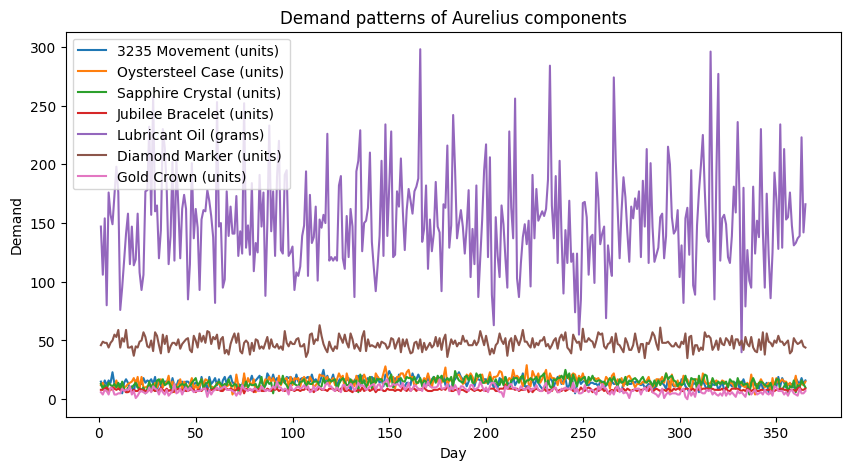

In [109]:
df_1.plot(x="Day", figsize=(10,5))

plt.title("Demand patterns of Aurelius components")
plt.ylabel("Demand")
plt.show()

In [110]:
component = "3235 Movement (units)"

D = inventory_data.loc[inventory_data["Component"] == component, "Annual Demand"].values[0]
S = inventory_data.loc[inventory_data["Component"] == component, "Ordering Cost"].values[0]

In [111]:
holding_values = np.linspace(200,2000,20)

EOQ_values = np.sqrt((2 * D * S) / holding_values)

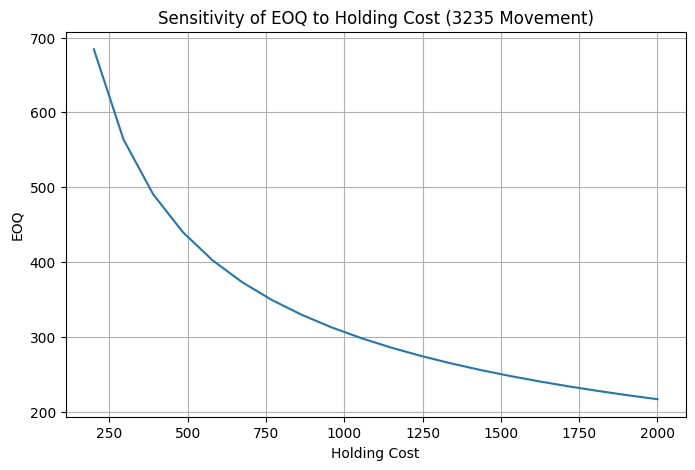

In [112]:
plt.figure(figsize=(8,5))

plt.plot(holding_values, EOQ_values)

plt.xlabel("Holding Cost")
plt.ylabel("EOQ")
plt.title("Sensitivity of EOQ to Holding Cost (3235 Movement)")

plt.grid(True)

plt.show()

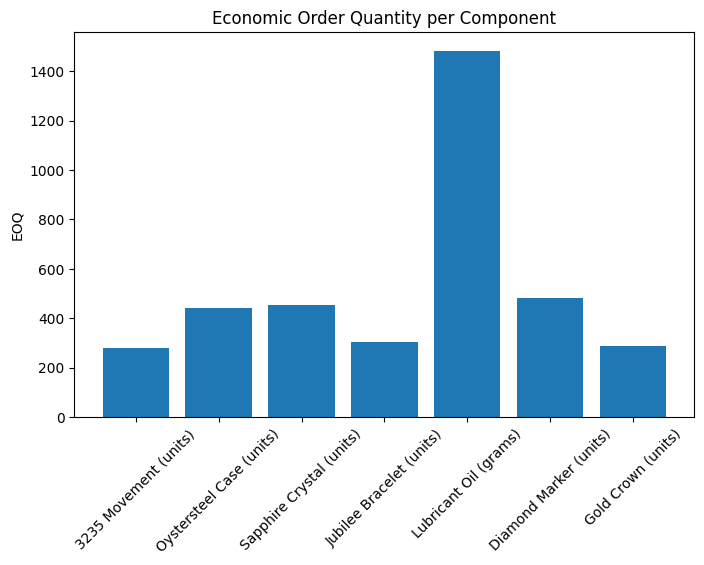

In [113]:
plt.figure(figsize=(8,5))

plt.bar(inventory_data["Component"], inventory_data["EOQ"])

plt.xticks(rotation=45)
plt.ylabel("EOQ")
plt.title("Economic Order Quantity per Component")

plt.show()

In [114]:
#useful parameters for the model:

# Lead time (tau)
tau = inventory_params["Lead Time"]

# Holding cost (h)
h = inventory_params["Holding Cost"]

# Ordering cost (K)
K = inventory_params["Ordering Cost"]

# sfaety levl
alpha= 0.95 #fixé random
tau.index = components
h.index = components
K.index = components

mean_demand = df_1[components].mean()
std_demand = df_1[components].std()
annual_demand = df_1[components].sum()

In [115]:
def calculate_optimal_T(annual_demand, K, h, working_days, working_weeks):

    EOQ = np.sqrt((2 * annual_demand * K) / h)

    total_working_days = working_days * working_weeks

    T_days = EOQ / (annual_demand / total_working_days)

    return T_days

In [116]:
from scipy.stats import norm

def calculate_order_up_to_level(mean_demand, std_demand, T, tau, alpha):

    protection_interval = T + tau

    mu_protection = mean_demand * protection_interval
    sigma_protection = std_demand * np.sqrt(protection_interval)

    S = mu_protection + norm.ppf(alpha) * sigma_protection

    return S

In [117]:
# Working calendar
working_days = 5
working_weeks = 52


In [118]:
T_optimal = calculate_optimal_T(annual_demand, K, h, working_days, working_weeks)

S_optimal = calculate_order_up_to_level(
    mean_demand,
    std_demand,
    T_optimal,
    tau,
    alpha
)

print("Optimal review period T* (days):") #review interval
print(T_optimal)

print("\nOrder-up-to level S*:") #target inventory
print(S_optimal)

Optimal review period T* (days):
3235 Movement (units)       13.957531
Oystersteel Case (units)    20.665813
Sapphire Crystal (units)    22.832066
Jubilee Bracelet (units)    27.112769
Lubricant Oil (grams)        7.010786
Diamond Marker (units)       7.187162
Gold Crown (units)          25.709831
dtype: float64

Order-up-to level S*:
3235 Movement (units)       1105.029484
Oystersteel Case (units)    1053.744222
Sapphire Crystal (units)     793.685590
Jubilee Bracelet (units)     510.813354
Lubricant Oil (grams)       3477.295752
Diamond Marker (units)      1391.985185
Gold Crown (units)           566.476150
dtype: float64


In [119]:
df_1.columns

Index(['Day', '3235 Movement (units)', 'Oystersteel Case (units)',
       'Sapphire Crystal (units)', 'Jubilee Bracelet (units)',
       'Lubricant Oil (grams)', 'Diamond Marker (units)',
       'Gold Crown (units)'],
      dtype='object')

In [120]:
df_1

,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
0,1,15,12,13,8,147,46,6
1,2,11,14,9,8,106,49,4
2,3,16,10,12,9,154,48,8
3,4,12,7,8,10,80,48,7
4,5,16,6,14,8,176,44,4
...,...,...,...,...,...,...,...,...
360,361,15,10,12,9,137,47,3
361,362,13,13,10,10,139,48,9
362,363,18,13,16,8,223,50,5
363,364,13,12,13,8,142,45,5


/tmp/ipykernel_173/4256649703.py:34: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  on_order = sum(qty for arrival, qty in pending_orders)


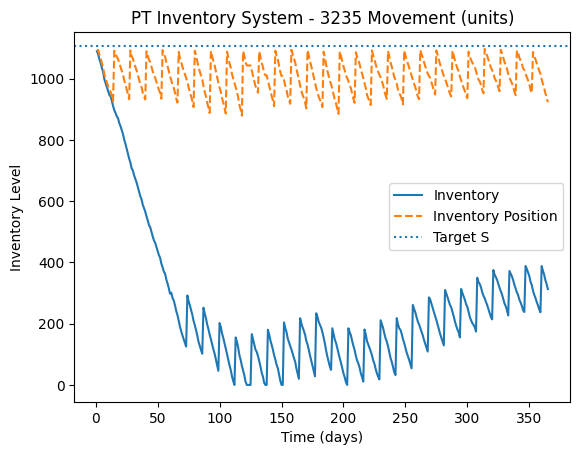

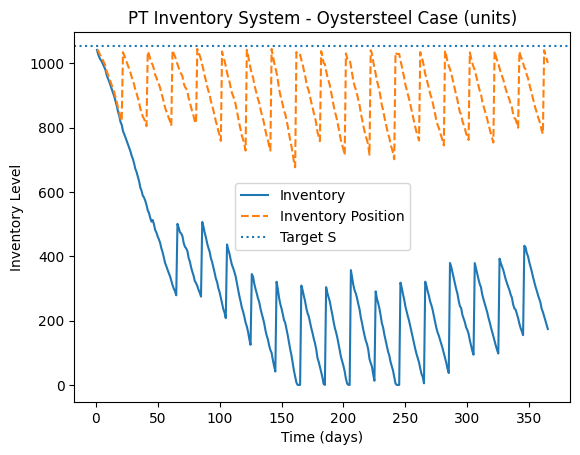

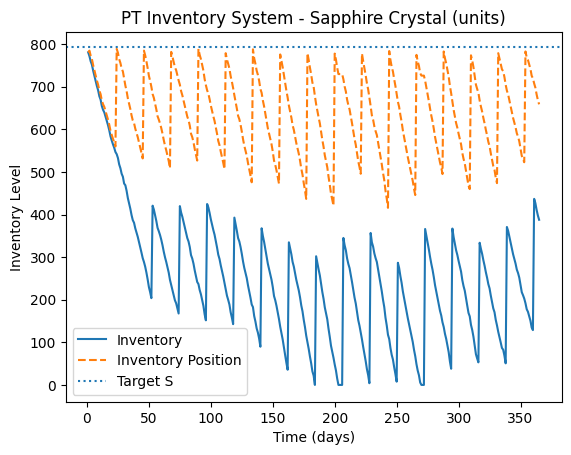

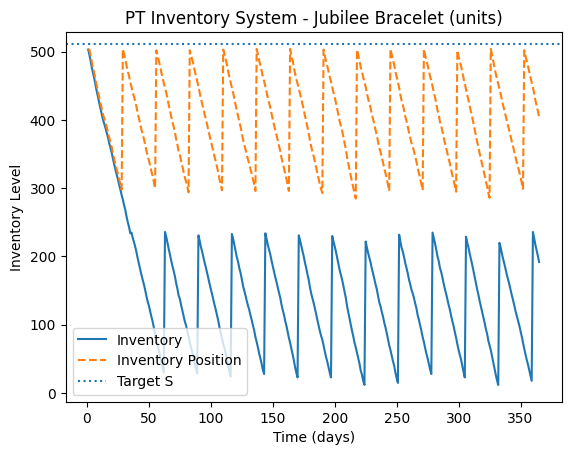

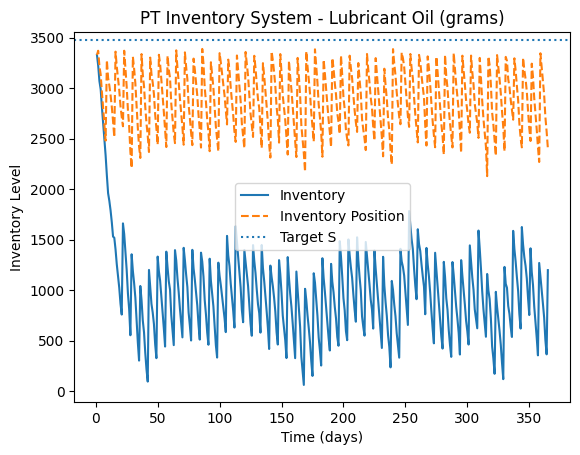

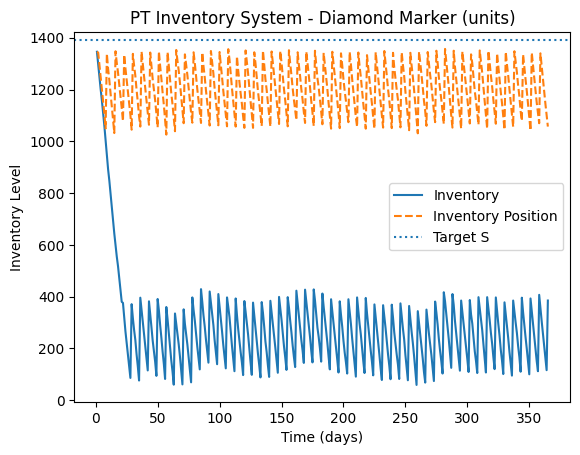

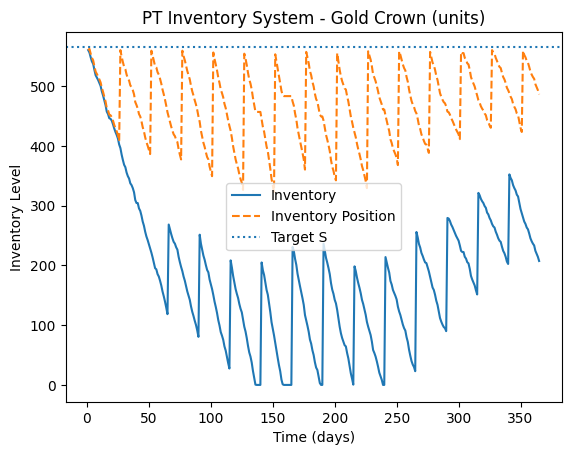

In [123]:
import matplotlib.pyplot as plt

time = df_1["Day"]

for comp in components:

    S = S_optimal[comp]
    T = int(T_optimal[comp])
    lead = int(tau[comp])

    current_inventory = S
    inventory = []
    inventory_position_list = []

    pending_orders = []

    for t, demand in enumerate(df_1[comp]):

        # 1. arrivée des commandes
        for order in pending_orders:
            if order[0] == t:
                current_inventory += order[1]

        # supprimer commandes reçues
        pending_orders = [o for o in pending_orders if o[0] != t]

        # 2. demande réelle
        current_inventory -= demand

        # éviter stock négatif (important)
        current_inventory = max(0, current_inventory)

        # 3. quantité en commande
        on_order = sum(qty for arrival, qty in pending_orders)

        # 4. inventory position
        inventory_position = current_inventory + on_order
        inventory_position_list.append(inventory_position)

        # 5. review périodique
        if t % T == 0:
            order_qty = S - inventory_position

            if order_qty > 0:
                arrival_day = t + lead
                pending_orders.append((arrival_day, order_qty))

        inventory.append(current_inventory)

    # 🔥 PLOT PROPRE
    plt.figure()
    plt.plot(time, inventory, label="Inventory")
    plt.plot(time, inventory_position_list, linestyle="--", label="Inventory Position")
    plt.axhline(S, linestyle=":", label="Target S")

    plt.xlabel("Time (days)")
    plt.ylabel("Inventory Level")
    plt.title(f"PT Inventory System - {comp}")

    plt.legend()
    plt.show()

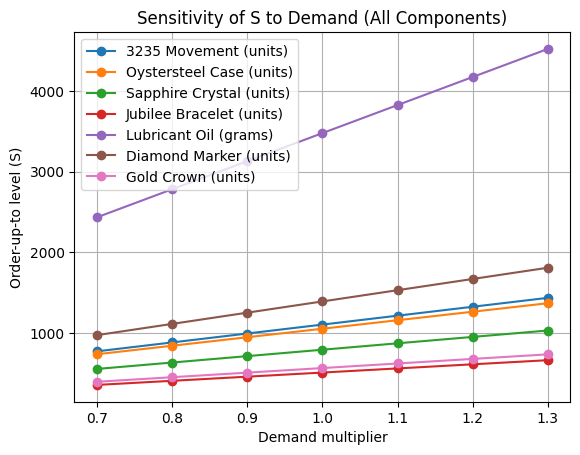

In [124]:
import matplotlib.pyplot as plt

scenarios = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]

plt.figure()

for comp in components:

    S_values = []

    for s in scenarios:
        new_mean = mean_demand[comp] * s
        new_std = std_demand[comp] * s

        S_new = calculate_order_up_to_level(
            new_mean,
            new_std,
            T_optimal[comp],
            tau[comp],
            alpha
        )

        S_values.append(S_new)

    #  UNE LIGNE PAR COMPOSANT
    plt.plot(scenarios, S_values, marker='o', label=comp)

#  mise en forme
plt.xlabel("Demand multiplier")
plt.ylabel("Order-up-to level (S)")
plt.title("Sensitivity of S to Demand (All Components)")

plt.legend()
plt.grid(True)

plt.show()